In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
# Read CSV File
#df = pd.read_csv("d:/Dataset/accepted_2007_to_2018Q4.csv", low_memory=False)
df_dummies = pd.read_csv("d:/Dataset/LC_Cleaned_Data_dummies.csv", low_memory=False)

In [3]:
#Now that columns are encoded, split loan grades using a df dictionary 
grades = df_dummies['grade'].unique()
grade_dfs = {}
for grade in grades:
    grade_dfs[grade] = df_dummies[df_dummies['grade'] == grade].reset_index(drop=True)

In [4]:
models = {}
scalers = {}
results = []

grades = sorted(df_dummies['grade'].dropna().unique())

for grade in grades:
    # 1. Split into X, y dataframes
    y = grade_dfs[grade]['loan_status_Charged Off']
    X = grade_dfs[grade].drop(
        columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade']
    )

    # 2. Split 80/20 for train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 3. Scale features
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Tune alpha using RidgeClassifierCV
    alpha_candidates = [0.1, 1.0, 10.0, 100.0]

    clf_cv = RidgeClassifierCV(
        alphas=alpha_candidates,
        cv=10
    )

    clf_cv.fit(X_train_scaled, y_train)

    # Save model and scaler
    models[grade] = clf_cv
    scalers[grade] = scaler

    # 5. Cross-validation AUC using the best alpha
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    ridge_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeClassifier(alpha=clf_cv.alpha_))
    ])

    cv_auc_scores = cross_val_score(
        ridge_pipeline,
        X,
        y,
        cv=cv,
        scoring='roc_auc'
    )

    cv_auc_mean = cv_auc_scores.mean()
    cv_auc_std = cv_auc_scores.std()

    # 6. Make predictions
    y_pred = clf_cv.predict(X_test_scaled)

    # 7. Decision scores for ROC-AUC
    y_scores = clf_cv.decision_function(X_test_scaled)

    # 8. Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_scores)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Save results for comparison table
    results.append({
        'grade': grade,
        'n_rows': len(X),
        'best_alpha': clf_cv.alpha_,
        'accuracy': accuracy,
        'roc_auc': auc_score,
        'cv_auc_mean': cv_auc_mean,
        'cv_auc_std': cv_auc_std,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'true_negative': tn,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by grade
results_df = results_df.sort_values('grade')

# Round values
results_df_rounded = results_df.round(4)

# Print comparison table
print("Ridge Classifier Results by Grade")
print(results_df_rounded)

# Output to CSV
results_df_rounded.to_csv("ridge_classifier_results_by_grade.csv", index=False)
    

Ridge Classifier Results by Grade
  grade  n_rows  best_alpha  accuracy  roc_auc  cv_auc_mean  cv_auc_std  \
0     A  235188         0.1    0.9396   0.6355       0.6358      0.0047   
1     B  393095         0.1    0.8660   0.6029       0.5984      0.0041   
2     C  382315         0.1    0.7755   0.5985       0.5996      0.0028   
3     D  201644         0.1    0.6963   0.6089       0.6046      0.0045   
4     E   94186         0.1    0.6232   0.6054       0.6078      0.0049   
5     F   32305       100.0    0.5837   0.6022       0.6060      0.0122   
6     G    9326         0.1    0.5713   0.5896       0.5886      0.0204   

   precision  recall  f1_score  true_negative  false_positive  false_negative  \
0     0.0000  0.0000    0.0000          44195               1            2842   
1     0.0000  0.0000    0.0000          68083               5           10531   
2     0.2222  0.0002    0.0005          59290              14           17155   
3     0.5333  0.0013    0.0026          2

In [5]:
coef_results = []

for grade, model in models.items():

    # Use the same X columns used when training
    X = grade_dfs[grade].drop(
        columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade'],
        errors='ignore'
    )

    # Flatten coefficients
    coefficients = model.coef_.ravel()

    for feature, coef in zip(X.columns, coefficients):
        coef_results.append({
            'feature': feature,
            'grade': grade,
            'coefficient': coef
        })

# Convert to DataFrame
coef_df = pd.DataFrame(coef_results)

# Pivot so features are rows and grades are columns
coef_table = coef_df.pivot(
    index='feature',
    columns='grade',
    values='coefficient'
)

# Optional: remove the column index name
coef_table.columns.name = None

# Round values
coef_table_rounded = coef_table.round(4)

# Print table
print(coef_table_rounded)

                                   A       B       C       D       E       F  \
feature                                                                        
avg_cur_bal                  -0.0102 -0.0206 -0.0272 -0.0349 -0.0384 -0.0365   
bc_util                       0.0011  0.0000 -0.0025 -0.0008 -0.0062 -0.0153   
dti                           0.0188  0.0277  0.0437  0.0462  0.0573  0.0696   
fico_range_low               -0.0267 -0.0373 -0.0438 -0.0427 -0.0475 -0.0409   
home_ownership_MORTGAGE       0.0241 -0.0175  0.0077  0.0245 -0.2215 -0.0208   
home_ownership_NONE          -0.0003  0.0022 -0.0010 -0.0007 -0.0045 -0.0067   
home_ownership_OTHER          0.0011  0.0025 -0.0010 -0.0003 -0.0068  0.0010   
home_ownership_OWN            0.0222  0.0007  0.0174  0.0244 -0.1261  0.0018   
home_ownership_RENT           0.0341  0.0057  0.0444  0.0641 -0.1690  0.0240   
inq_last_6mths                0.0114  0.0195  0.0204  0.0188  0.0161  0.0098   
int_rate                      0.0192  0.

In [6]:
coef_table_rounded.to_csv("ridge_coefficients_by_grade_wide.csv")

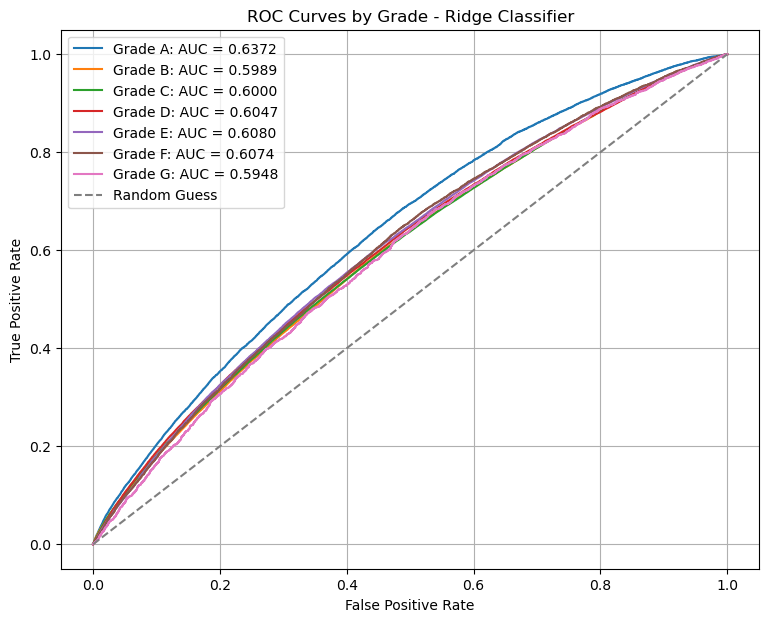

In [7]:
# Plot the ROC/AUC Curve for all Grades
plt.figure(figsize=(9, 7))

for grade in sorted(models.keys()):

    model = models[grade]
    scaler = scalers[grade]

    y = grade_dfs[grade]['loan_status_Charged Off']
    X = grade_dfs[grade].drop(
        columns=['loan_status_Charged Off', 'loan_status_Fully Paid', 'grade'],
        errors='ignore'
    )

    X_scaled = scaler.transform(X)

    y_scores = model.decision_function(X_scaled)

    fpr, tpr, thresholds = roc_curve(y, y_scores)
    auc_score = roc_auc_score(y, y_scores)

    plt.plot(fpr, tpr, label=f"Grade {grade}: AUC = {auc_score:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Grade - Ridge Classifier")
plt.legend()
plt.grid(True)
plt.show()